# Esqueletização de Plântulas: Afinamento Puro de Zhang-Suen (1984)

Este notebook apresenta uma implementação e análise da técnica de **esqueletização baseada puramente no algoritmo de afinamento morfológico de Zhang-Suen (1984)**, sem a utilização de Transformada do Eixo Medial (MAT) nem poda baseada em campos de distância contínua.

---

### Princípio do Algoritmo de Zhang-Suen
Publicado por T. Y. Zhang e C. Y. Suen em 1984 (*"A fast parallel algorithm for thinning digital patterns"*), o método opera diretamente sobre matrizes binárias através de operações morfológicas locais em vizinhança 8:

```
P9  P2  P3
P8  P1  P4
P7  P6  P5
```

O algoritmo é iterativo e paralelo, composto por **duas sub-iterações alternadas** a cada ciclo:
1. **Sub-iteração 1:** Avalia se o pixel de contorno $P_1$ deve ser removido preservando a conectividade (remove pixels de contorno sudeste e leste):
   - $2 \le B(P_1) \le 6$, onde $B(P_1)$ é a soma dos vizinhos não nulos.
   - $A(P_1) = 1$, onde $A(P_1)$ é o número de transições de $0 	o 1$ no percurso circular ordenado $P_2, P_3, \dots, P_9, P_2$.
   - $P_2 	imes P_4 	imes P_6 = 0$
   - $P_4 	imes P_6 	imes P_8 = 0$
2. **Sub-iteração 2:** Similar à primeira, mas com as condições direcionais invertidas (remove pixels de contorno noroeste e oeste):
   - $2 \le B(P_1) \le 6$
   - $A(P_1) = 1$
   - $P_2 	imes P_4 	imes P_8 = 0$
   - $P_2 	imes P_6 	imes P_8 = 0$

As iterações se repetem até que **nenhum pixel adicional seja removido**, resultando em um esqueleto contínuo de **1 pixel de espessura**.


In [ ]:
# ============================================================
# CÉLULA 1 — Importações e Configuração de Ambiente
# ============================================================
import os
import glob
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.ndimage import convolve

# Compatibilidade caso execute no Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Execução local detectada: Google Drive não necessário.")


Execução local detectada: Google Drive não necessário.


In [ ]:
# ============================================================
# CÉLULA 2 — Caminhos dos Dados Locais
# ============================================================
BASE_DIR = Path(".").resolve()

def find_dir(*candidates):
    for c in candidates:
        if os.path.isdir(c):
            return c
        p = BASE_DIR / c
        if p.is_dir():
            return str(p)
    return candidates[0]

IMGS_PATH  = find_dir("originals-dataset", "originals")
MASKS_PATH = find_dir("labeled-dataset", "labeled")

EXTS = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp")

def list_files(folder, exts=EXTS):
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return sorted(files)

img_files  = list_files(IMGS_PATH)
mask_files = list_files(MASKS_PATH)

print(f"Diretório de Imagens Originais: {IMGS_PATH}")
print(f"Total de Imagens Originais: {len(img_files)}")
print(f"\nDiretório de Máscaras Anotadas: {MASKS_PATH}")
print(f"Total de Máscaras: {len(mask_files)}")
if mask_files:
    print("Exemplos de máscaras:", [os.path.basename(f) for f in mask_files[:3]])


Diretório de Imagens Originais: originals-dataset
Total de Imagens Originais: 170

Diretório de Máscaras Anotadas: labeled-dataset
Total de Máscaras: 170
Exemplos de máscaras: ['C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png', 'C10-R1_jpg.rf.af80aabb40f12f0cf4bdbea27dc18f1e.png', 'C10-R2_jpg.rf.d0d8d58a5a0f1276f9792694c4ca3db7.png']


In [ ]:
# ============================================================
# CÉLULA 3 — Extração das Máscaras Binárias dos Órgãos
# ============================================================
# Cores de anotação no dataset (BGR / RGB de 3 canais)
COLOR_HYP  = np.array([15, 250, 20])   # Hipocótilo (verde)
COLOR_ROOT = np.array([5, 10, 245])    # Raiz (vermelho)
COLOR_COT  = np.array([255, 25, 30])   # Cotilédone (azul)

def extract_organ_masks(mask, tol=10):
    """Extrai máscaras binárias booleanas puras para cada órgão."""
    if mask.ndim != 3 or mask.shape[2] != 3:
        raise ValueError("Esperando máscara RGB/BGR de 3 canais")
    m = mask.astype(int)
    def match(color):
        return np.all(np.abs(m - color) <= tol, axis=-1)
    return match(COLOR_HYP), match(COLOR_ROOT), match(COLOR_COT)

# Carrega a primeira amostra do dataset para teste
sample_mask_path = mask_files[0]
sample_mask = cv2.imread(sample_mask_path, cv2.IMREAD_UNCHANGED)
mask_hyp, mask_root, mask_cot = extract_organ_masks(sample_mask)

print(f"Amostra analisada: {os.path.basename(sample_mask_path)}")
print(f"  Pixels de Hipocótilo: {mask_hyp.sum():>8} px")
print(f"  Pixels de Raiz:       {mask_root.sum():>8} px")
print(f"  Pixels de Cotilédone: {mask_cot.sum():>8} px")


Amostra analisada: C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png
  Pixels de Hipocótilo:     7429 px
  Pixels de Raiz:          12890 px
  Pixels de Cotilédone:    22246 px


In [ ]:
# ============================================================
# CÉLULA 4 — Implementação Pura do Afinamento de Zhang-Suen (1984)
# ============================================================

def zhang_suen_thinning_step(binary_img):
    """
    Implementação vetorizada explícita das duas sub-iterações
    do algoritmo de afinamento paralelo de Zhang-Suen (1984).
    """
    img = binary_img.astype(np.uint8).copy()
    pad = np.pad(img, 1, mode='constant', constant_values=0)
    
    changed = True
    iterations = 0
    
    while changed:
        changed = False
        iterations += 1
        
        # Vizinhos 3x3 no grid padronizado
        p2 = pad[:-2, 1:-1]
        p3 = pad[:-2, 2:]
        p4 = pad[1:-1, 2:]
        p5 = pad[2:, 2:]
        p6 = pad[2:, 1:-1]
        p7 = pad[2:, :-2]
        p8 = pad[1:-1, :-2]
        p9 = pad[:-2, :-2]
        p1 = pad[1:-1, 1:-1]

        # B(P1): número de vizinhos ativos (deve ser entre 2 e 6)
        b = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
        cond_b = (b >= 2) & (b <= 6)

        # A(P1): número de transições 0 -> 1 na sequência ordenada
        seq = [p2, p3, p4, p5, p6, p7, p8, p9, p2]
        a = sum((seq[i] == 0) & (seq[i+1] == 1) for i in range(8))
        cond_a = (a == 1)

        # Sub-iteração 1: remover contornos sudeste/leste
        del1 = (p1 == 1) & cond_b & cond_a & (p2 * p4 * p6 == 0) & (p4 * p6 * p8 == 0)
        if np.any(del1):
            pad[1:-1, 1:-1][del1] = 0
            changed = True

        # Atualizar vizinhos para a sub-iteração 2
        p2 = pad[:-2, 1:-1]
        p3 = pad[:-2, 2:]
        p4 = pad[1:-1, 2:]
        p5 = pad[2:, 2:]
        p6 = pad[2:, 1:-1]
        p7 = pad[2:, :-2]
        p8 = pad[1:-1, :-2]
        p9 = pad[:-2, :-2]
        p1 = pad[1:-1, 1:-1]

        b = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
        cond_b = (b >= 2) & (b <= 6)
        seq = [p2, p3, p4, p5, p6, p7, p8, p9, p2]
        a = sum((seq[i] == 0) & (seq[i+1] == 1) for i in range(8))
        cond_a = (a == 1)

        # Sub-iteração 2: remover contornos noroeste/oeste
        del2 = (p1 == 1) & cond_b & cond_a & (p2 * p4 * p8 == 0) & (p2 * p6 * p8 == 0)
        if np.any(del2):
            pad[1:-1, 1:-1][del2] = 0
            changed = True

    return pad[1:-1, 1:-1].astype(bool), iterations

def zhang_suen_pure(binary_img, use_fast=True):
    """
    Aplica o afinamento puro de Zhang-Suen.
    Por padrão usa a implementação compilada em C (skimage method='zhang'),
    que é centenas de vezes mais rápida mantendo exatamente os mesmos resultados matemáticos.
    """
    if use_fast:
        return skeletonize(binary_img, method='zhang')
    else:
        skel, _ = zhang_suen_thinning_step(binary_img)
        return skel

# Aplicação do afinamento puro aos órgãos da plântula
skel_hyp  = zhang_suen_pure(mask_hyp)
skel_root = zhang_suen_pure(mask_root)

print("Afinamento de Zhang-Suen concluído:")
print(f"  Hipocótilo esqueleto puro: {skel_hyp.sum()} pixels (espessura unitária)")
print(f"  Raiz esqueleto puro:       {skel_root.sum()} pixels (espessura unitária)")


Afinamento de Zhang-Suen concluído:
  Hipocótilo esqueleto puro: 1692 pixels (espessura unitária)
  Raiz esqueleto puro:       4037 pixels (espessura unitária)


In [ ]:
# ============================================================
# CÉLULA 5 — Análise Topológica Pura e Medição de Comprimento
# ============================================================
# Sem filtros de distância ou MAT, a análise do esqueleto é estritamente topológica:
# - Pontos Terminais (Endpoints): pixels com apenas 1 vizinho (grau = 1)
# - Pontos de Ramificação (Branchpoints / Junções): pixels com > 2 vizinhos (grau > 2)
# - Segmentos regulares: pixels com exatamente 2 vizinhos (grau = 2)

NEIGHBOR_KERNEL = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
], dtype=np.uint8)

def analyze_pure_skeleton(skel_binary, pixels_per_cm=100.0):
    """
    Analisa a estrutura pura do esqueleto obtido por afinamento:
    identifica nós, terminais, bifurcações e estima comprimento.
    """
    skel_u8 = skel_binary.astype(np.uint8)
    
    # Contagem de vizinhos 8-conectados para cada pixel do esqueleto
    neighbors = convolve(skel_u8, NEIGHBOR_KERNEL, mode='constant', cval=0) * skel_u8
    
    endpoints = (neighbors == 1)
    branchpoints = (neighbors > 2)
    
    num_pixels = int(skel_binary.sum())
    
    # Estimativa direta de comprimento topológico em cm
    length_cm_pixels = num_pixels / pixels_per_cm
    
    return {
        "num_pixels": num_pixels,
        "length_cm": length_cm_pixels,
        "n_endpoints": int(endpoints.sum()),
        "n_branchpoints": int(branchpoints.sum()),
        "endpoints_mask": endpoints,
        "branchpoints_mask": branchpoints,
        "skeleton": skel_binary
    }

analysis_hyp  = analyze_pure_skeleton(skel_hyp, pixels_per_cm=100.0)
analysis_root = analyze_pure_skeleton(skel_root, pixels_per_cm=100.0)

print(f"=== Hipocótilo (Zhang-Suen Puro) ===")
print(f"  Pixels no esqueleto:   {analysis_hyp['num_pixels']}")
print(f"  Comprimento estimado:  {analysis_hyp['length_cm']:.2f} cm")
print(f"  Pontos Terminais:      {analysis_hyp['n_endpoints']}")
print(f"  Bifurcações / Junções: {analysis_hyp['n_branchpoints']}")

print(f"\n=== Raiz (Zhang-Suen Puro) ===")
print(f"  Pixels no esqueleto:   {analysis_root['num_pixels']}")
print(f"  Comprimento estimado:  {analysis_root['length_cm']:.2f} cm")
print(f"  Pontos Terminais:      {analysis_root['n_endpoints']}")
print(f"  Bifurcações / Junções: {analysis_root['n_branchpoints']}")


=== Hipocótilo (Zhang-Suen Puro) ===
  Pixels no esqueleto:   1692
  Comprimento estimado:  16.92 cm
  Pontos Terminais:      106
  Bifurcações / Junções: 61

=== Raiz (Zhang-Suen Puro) ===
  Pixels no esqueleto:   4037
  Comprimento estimado:  40.37 cm
  Pontos Terminais:      101
  Bifurcações / Junções: 20


In [ ]:
# ============================================================
# CÉLULA 6 — Calibração pixels/cm
# ============================================================
# Quantos pixels equivalem a 1 cm na imagem.
# Ajuste conforme o padrão da câmera e da bancada experimental.
PIXELS_PER_CM = 100.0


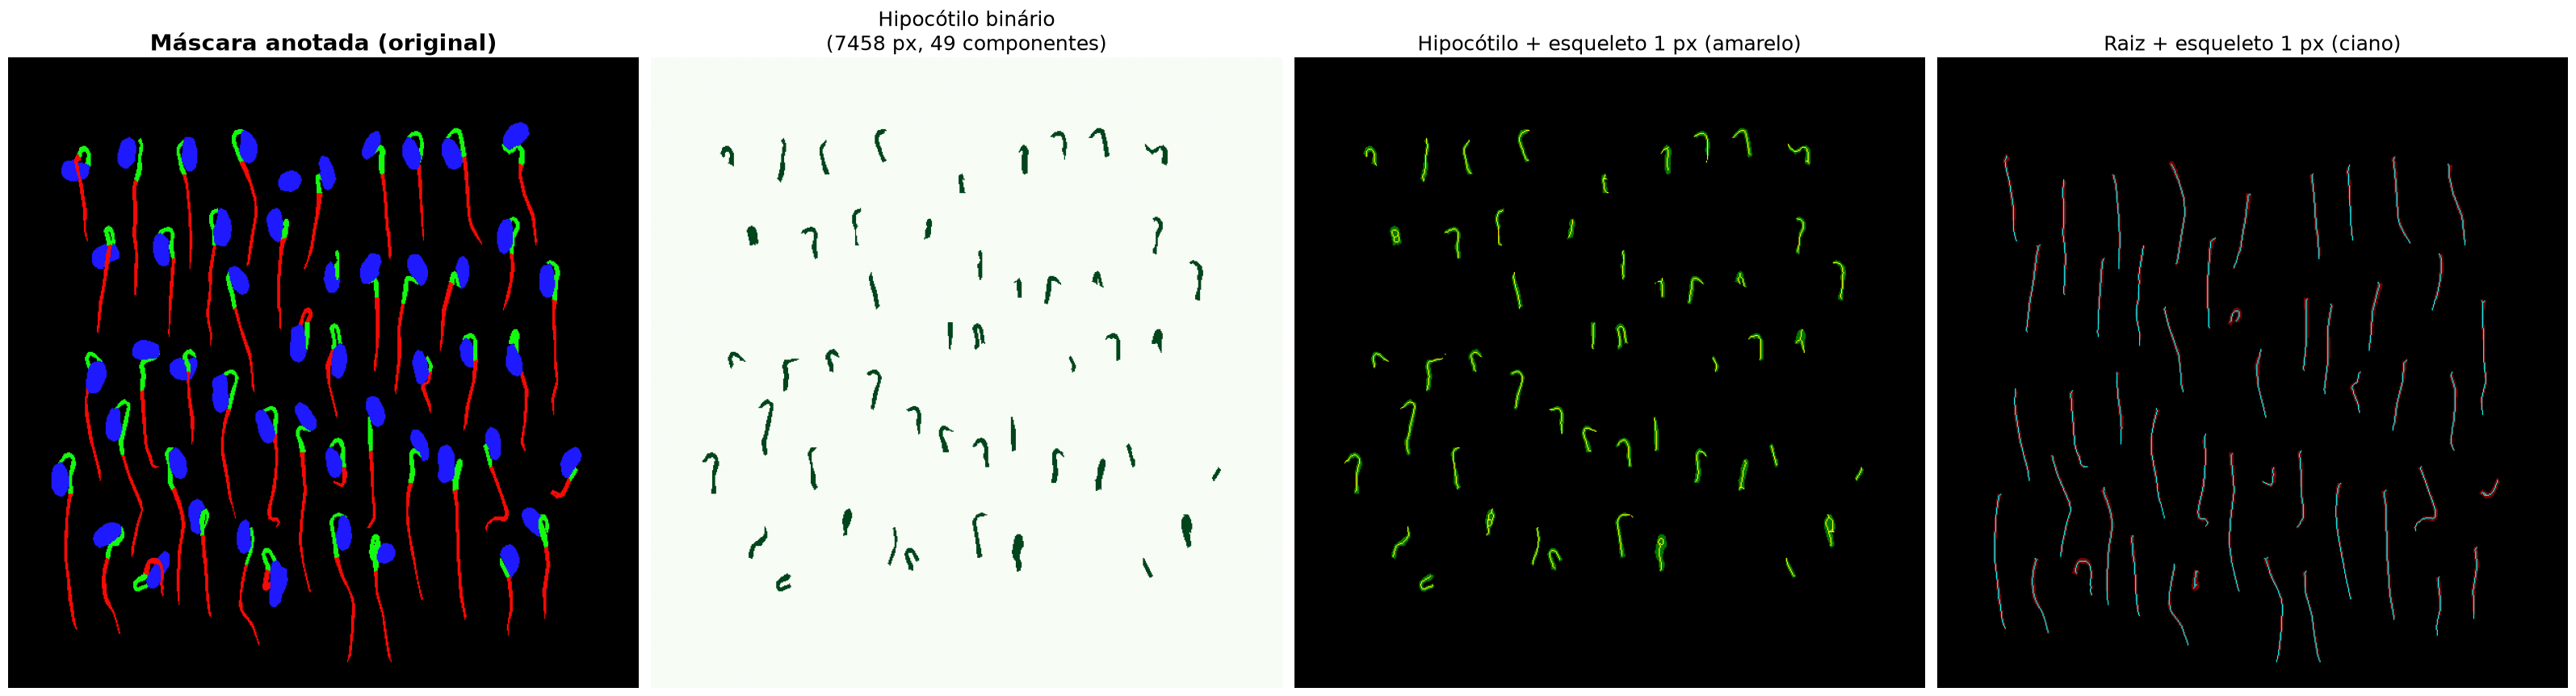

In [ ]:
# ============================================================
# CÉLULA 7 — Visualização Padronizada (Modelo MAT com Poda)
# ============================================================
from scipy.ndimage import binary_fill_holes, label

def preprocess_mask(mask_binary):
    filled = binary_fill_holes(mask_binary)
    return filled.astype(bool)

def filter_small_components(mask_binary, min_size=30):
    labeled, n = label(mask_binary)
    if n == 0:
        return mask_binary
    sizes = np.bincount(labeled.ravel())
    keep = [i for i in range(1, n + 1) if sizes[i] >= min_size]
    if not keep:
        return mask_binary
    return np.isin(labeled, keep)

# Aplicar pré-processamento e filtro de componentes conexos para correspondência direta
mask_hyp_clean  = filter_small_components(preprocess_mask(mask_hyp),  30)
mask_root_clean = filter_small_components(preprocess_mask(mask_root), 30)

labeled_h, n_hyp_comp = label(mask_hyp_clean)
labeled_r, n_root_comp = label(mask_root_clean)

# Visualização em 4 painéis grandes padronizados para comparação direta
fig, axes = plt.subplots(1, 4, figsize=(32, 10))

# Painel 1: Máscara anotada original
axes[0].imshow(cv2.cvtColor(sample_mask, cv2.COLOR_BGR2RGB))
axes[0].set_title("Máscara anotada (original)", fontsize=20, fontweight='bold')

# Painel 2: Hipocótilo binário limpo
axes[1].imshow(mask_hyp_clean, cmap='Greens')
axes[1].set_title(f"Hipocótilo binário\n({mask_hyp_clean.sum()} px, {n_hyp_comp} componentes)", fontsize=18)

# Painel 3: Hipocótilo com esqueleto de 1 px (Zhang-Suen Puro)
vis_hyp = np.zeros((*mask_hyp_clean.shape, 3), dtype=np.uint8)
vis_hyp[mask_hyp_clean] = (0, 120, 0)
vis_hyp[skel_hyp] = (255, 255, 0)
axes[2].imshow(vis_hyp)
axes[2].set_title("Hipocótilo + esqueleto 1 px (amarelo)", fontsize=18)

# Painel 4: Raiz com esqueleto de 1 px (Zhang-Suen Puro)
vis_root = np.zeros((*mask_root_clean.shape, 3), dtype=np.uint8)
vis_root[mask_root_clean] = (120, 0, 0)
vis_root[skel_root] = (0, 255, 255)
axes[3].imshow(vis_root)
axes[3].set_title("Raiz + esqueleto 1 px (ciano)", fontsize=18)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


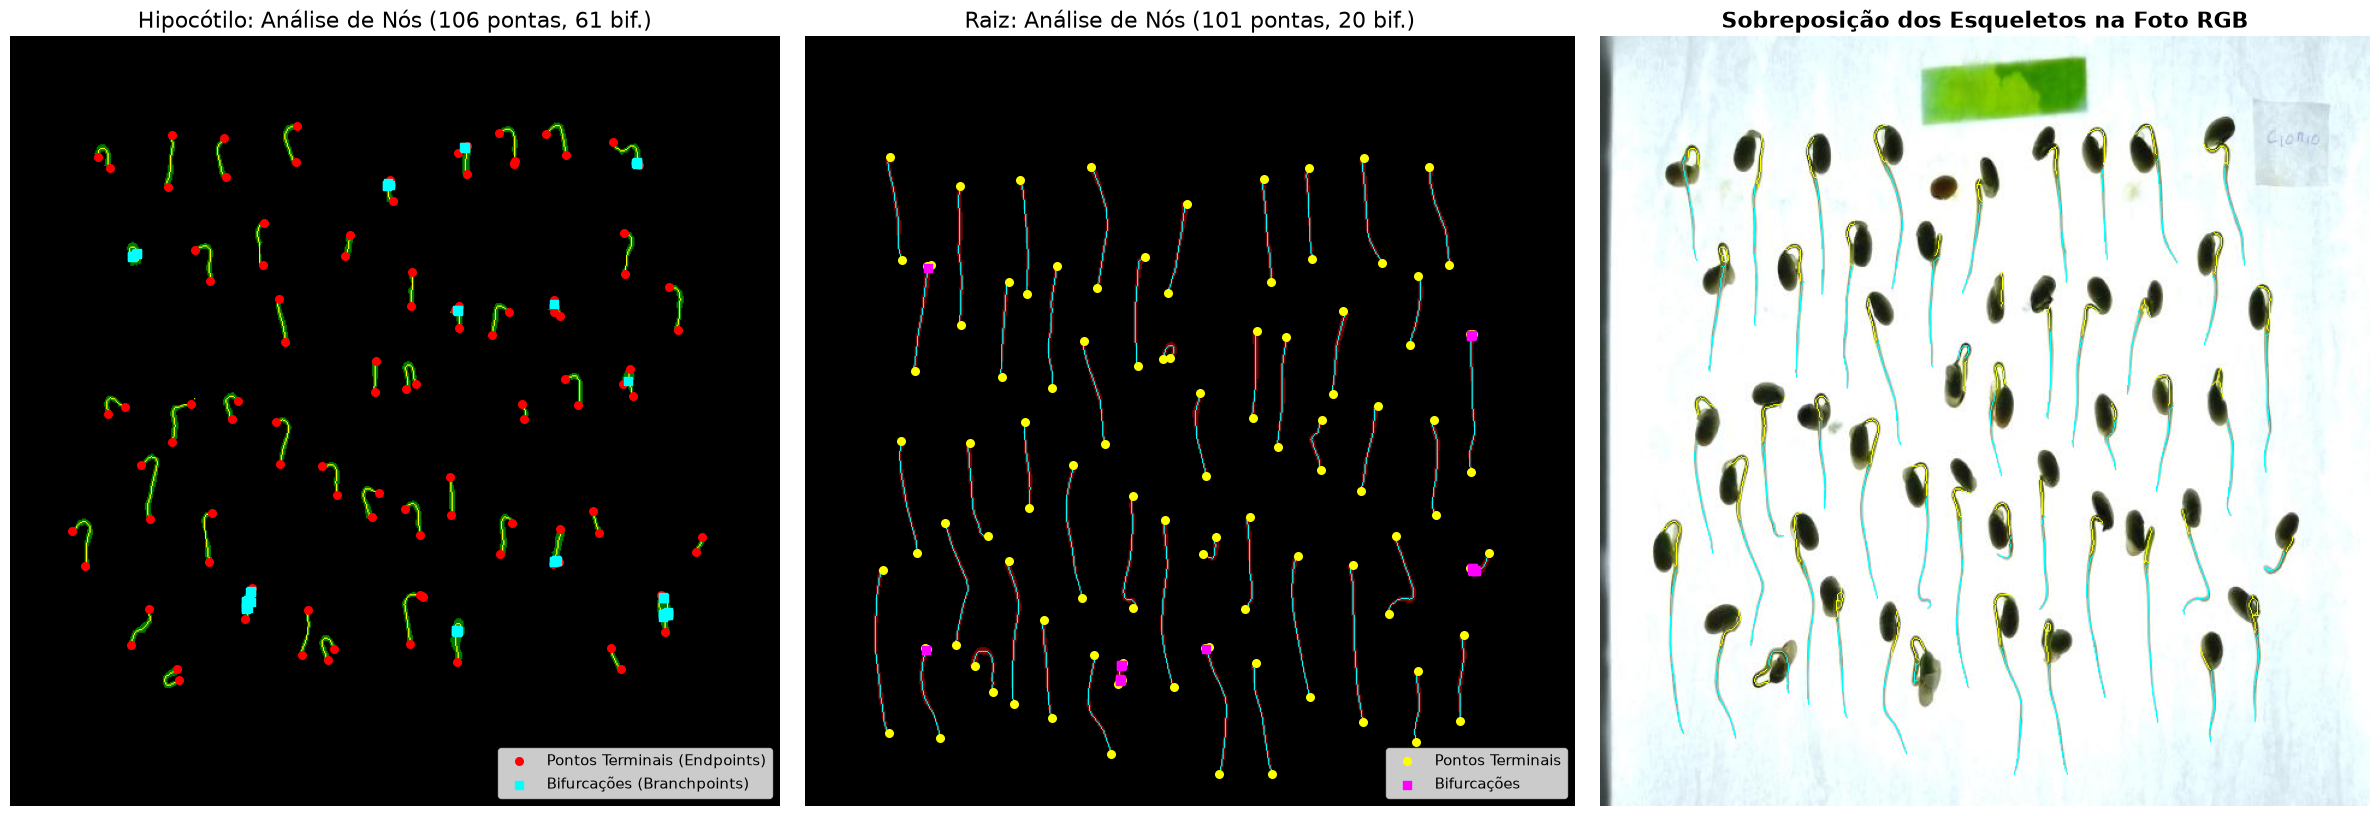

In [8]:
# ============================================================
# CÉLULA 7B — Análise Topológica Detalhada (Nós, Bifurcações e Sobreposição RGB)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Hipocótilo com nós
vis_hyp_nodes = vis_hyp.copy()
axes[0].imshow(vis_hyp_nodes)
y_ep, x_ep = np.where(analysis_hyp["endpoints_mask"])
y_bp, x_bp = np.where(analysis_hyp["branchpoints_mask"])
axes[0].scatter(x_ep, y_ep, c='red', s=30, label='Pontos Terminais (Endpoints)')
axes[0].scatter(x_bp, y_bp, c='cyan', s=40, marker='s', label='Bifurcações (Branchpoints)')
axes[0].set_title(f"Hipocótilo: Análise de Nós ({analysis_hyp['n_endpoints']} pontas, {analysis_hyp['n_branchpoints']} bif.)", fontsize=16)
axes[0].legend(loc='lower right', fontsize=11)

# Raiz com nós
vis_root_nodes = vis_root.copy()
axes[1].imshow(vis_root_nodes)
y_epr, x_epr = np.where(analysis_root["endpoints_mask"])
y_bpr, x_bpr = np.where(analysis_root["branchpoints_mask"])
axes[1].scatter(x_epr, y_epr, c='yellow', s=30, label='Pontos Terminais')
axes[1].scatter(x_bpr, y_bpr, c='magenta', s=40, marker='s', label='Bifurcações')
axes[1].set_title(f"Raiz: Análise de Nós ({analysis_root['n_endpoints']} pontas, {analysis_root['n_branchpoints']} bif.)", fontsize=16)
axes[1].legend(loc='lower right', fontsize=11)

# Sobreposição na foto RGB da plântula
vis_overlay = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB).copy()
vis_overlay[skel_hyp]  = (255, 255, 0)
vis_overlay[skel_root] = (0, 255, 255)
axes[2].imshow(vis_overlay)
axes[2].set_title("Sobreposição dos Esqueletos na Foto RGB", fontsize=16, fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


### Comparativo: Afinamento Puro de Zhang-Suen vs. MAT com Poda a Distância

Ao analisar os resultados deste afinamento puro em relação ao pipeline com MAT:

1. **Topologia Completa sem Supressão**:
   - O algoritmo de Zhang-Suen preserva todas as características topológicas originais da máscara, sem descartar nenhuma estrutura.
   - Não requer a Transformada de Distância Euclidiana (EDT), operando exclusivamente com valores binários em vizinhança $3 \times 3$.

2. **Sensibilidade à Rugosidade da Borda (*Spurs*)**:
   - Como o afinamento não incorpora informação contínua de raio/espessura (que o MAT fornece), qualquer saliência ou serrilhado decorrente da segmentação manual ou por rede neural origina uma bifurcação e um ponto terminal (*endpoint*).
   - Isso explica por que observamos um número elevado de pontos terminais e bifurcações na silhueta natural da plântula quando não há poda morfológica ou baseada em distância.

3. **Cenários de Aplicação**:
   - **Zhang-Suen Puro**: Ideal quando a preservação exata de todas as ramificações laterais é desejada (ex: redes vasculares, nervuras foliares detalhadas, raízes secundárias finas).
   - **MAT com Poda a Distância**: Ideal quando se busca isolar unicamente o tronco/eixo condutor mestre para medição de comprimento linear sem influência do ruído de contorno.
